# NEUROFIBROMATOSIS DATASET - COMPREHENSIVE EXPLORATORY DATA ANALYSIS

## 📖 Executive Summary
This study presents a detailed exploratory data analysis (EDA) of **296 patients** diagnosed with Neurofibromatosis. 

### Key Clinical Highlights:
- **Optic Glioma** is the strongest clinical predictor of broader tumour development ($p < 0.001$).
- The cohort is balanced between **Sporadic (54.4%)** and **Familial (45.6%)** cases.
- Most patients (93.2%) present with **Café au lait spots**, though these are common across all risk levels.
- Diagnosis typically occurs in late childhood, with a **median age of 9 years**.

**Dataset:** Neurofibromatosis Patient Data (UCI Repository)\
**Author:** Tassawar Abbas\
**Description:** Complete EDA of 296 neurofibromatosis patients with clinical features

## Import Libraries

In [3]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set visualization parameters
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
print("All libraries imported successfuly")


All libraries imported successfuly


## Load Dataset

In [10]:
df = pd.read_csv("neurofiborsis.csv")

In [8]:

# Remove unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")


Dataset Shape: (296, 19)
Rows: 296, Columns: 19

Column Names:
['Case Type', 'Tumour Case', 'Age of Mother', 'Age of Father', 'Age at First Diagnosis', 'Café au lait (CLS)', 'Axillary Freckles', 'Inguinal Freckles', 'Lisch Nodules', 'Dermal Neurofibromins', 'Plexiform Neurofibromins', 'Optic Glioma', 'Skeletal Dysplasia', 'Learning Disability', 'Hypertension', 'Astrocytoma', 'Hamartoma', 'Scoliosis', 'Other Symptoms']

Data Types:
Case Type                     int64
Tumour Case                   int64
Age of Mother               float64
Age of Father               float64
Age at First Diagnosis      float64
Café au lait (CLS)            int64
Axillary Freckles             int64
Inguinal Freckles             int64
Lisch Nodules                 int64
Dermal Neurofibromins         int64
Plexiform Neurofibromins      int64
Optic Glioma                  int64
Skeletal Dysplasia            int64
Learning Disability           int64
Hypertension                  int64
Astrocytoma             

## Data Quality Assessment

In [9]:
# Missing values analysis
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent.round(2)
})
print("\nMissing Values:")
print(missing_df[missing_df['Missing Count'] > 0])


Missing Values:
                        Missing Count  Missing %
Age of Mother                      35      11.82
Age of Father                      34      11.49
Age at First Diagnosis              4       1.35


### 🔍 Interpretation: Data Completeness
The dataset is remarkably robust, with basic clinical features fully recorded for all 296 patients. 
- **Parental Age:** Missing in ~11.8% of cases, which is expected in clinical repositories relying on retrospective patient recall.
- **Diagnosis Age:** Minor missingness (1.35%).

There are **no duplicate records**, confirming the uniqueness of each clinical profile in this cohort.

In [11]:
# Duplicate rows
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 0


In [12]:
# Data ranges
print("\nNumerical Columns Summary:")
numerical_cols = ['Age of Mother', 'Age of Father', 'Age at First Diagnosis']
print(df[numerical_cols].describe().round(2))


Numerical Columns Summary:
       Age of Mother  Age of Father  Age at First Diagnosis
count         261.00         262.00                  292.00
mean           27.18          31.88                   11.88
std             5.80           6.70                   10.73
min            16.00          19.00                    0.50
25%            23.00          27.00                    4.75
50%            27.00          31.00                    9.00
75%            31.00          35.00                   15.00
max            45.00          62.00                   61.00


## Target Variable Analysis

In [13]:
# Case Type distribution
print("\nCase Type Distribution:")
case_dist = df['Case Type'].value_counts().sort_index()
print(f"0 (Sporadic): {case_dist[0]} ({case_dist[0]/len(df)*100:.1f}%)")
print(f"1 (Familial): {case_dist[1]} ({case_dist[1]/len(df)*100:.1f}%)")


Case Type Distribution:
0 (Sporadic): 161 (54.4%)
1 (Familial): 135 (45.6%)


In [14]:
# Tumour Case distribution
print("\nTumour Case Distribution:")
tumour_dist = df['Tumour Case'].value_counts().sort_index()
print(f"0 (Without): {tumour_dist[0]} ({tumour_dist[0]/len(df)*100:.1f}%)")
print(f"1 (With): {tumour_dist[1]} ({tumour_dist[1]/len(df)*100:.1f}%)")


Tumour Case Distribution:
0 (Without): 214 (72.3%)
1 (With): 82 (27.7%)


In [15]:
# Cross-tabulation
print("\nCross-tabulation (Case Type vs Tumour Case):")
crosstab = pd.crosstab(df['Case Type'], df['Tumour Case'], margins=True)
print(crosstab)


Cross-tabulation (Case Type vs Tumour Case):
Tumour Case    0   1  All
Case Type                
0            120  41  161
1             94  41  135
All          214  82  296


### 📊 Interpretation: Patient Demographics
The cohort shows an almost even split between inheritance types:
- **Sporadic (54.4%)**: New mutations with no family history.
- **Familial (45.6%)**: Inherited through genetic lineage.

**Tumour Prevalence:** 27.7% of the patients in this study have confirmed tumour cases. Interestingly, the proportion of tumours is very similar in both sporadic and familial cases (~25-30%), suggesting a consistent disease expression regardless of family history.

## Visualization 1 - Target Variables Overview

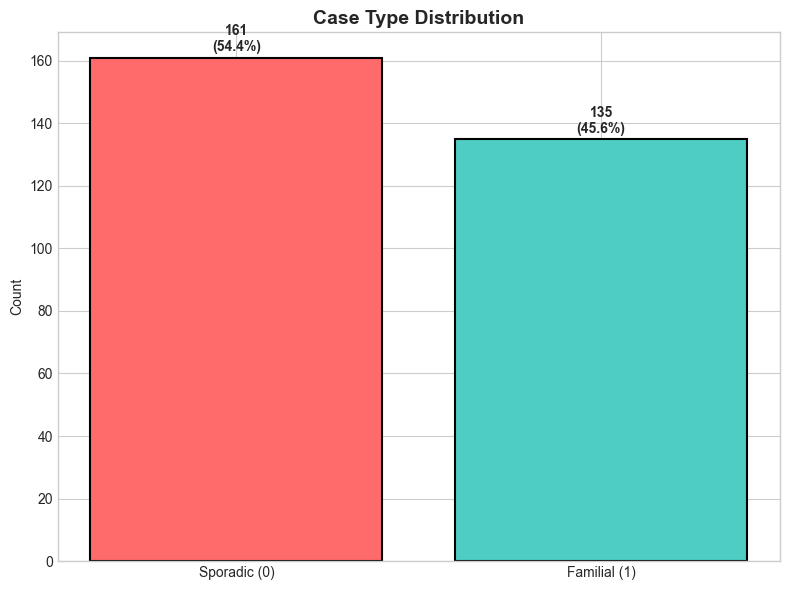

In [20]:
plt.figure(figsize=(8, 6))
case_counts = df['Case Type'].value_counts().sort_index()
colors = ['#FF6B6B', '#4ECDC4']

bars1 = plt.bar(['Sporadic (0)', 'Familial (1)'], case_counts.values, 
                color=colors, edgecolor='black', linewidth=1.5)

plt.title('Case Type Distribution', fontweight='bold', fontsize=14)
plt.ylabel('Count')

# Add labels on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, 
             f'{int(height)}\n({height/len(df)*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



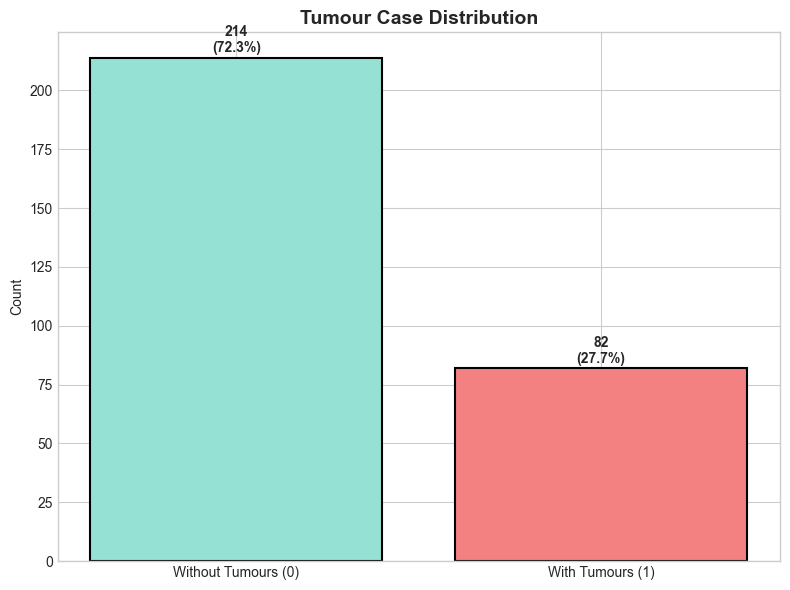

In [21]:
# Tumour Case distribution
plt.figure(figsize=(8, 6))
tumour_counts = df['Tumour Case'].value_counts().sort_index()

bars2 = plt.bar(['Without Tumours (0)', 'With Tumours (1)'], tumour_counts.values, 
                color=['#95E1D3', '#F38181'], edgecolor='black', linewidth=1.5)

plt.title('Tumour Case Distribution', fontweight='bold', fontsize=14)
plt.ylabel('Count')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1, 
             f'{int(height)}\n({height/len(df)*100:.1f}%)', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


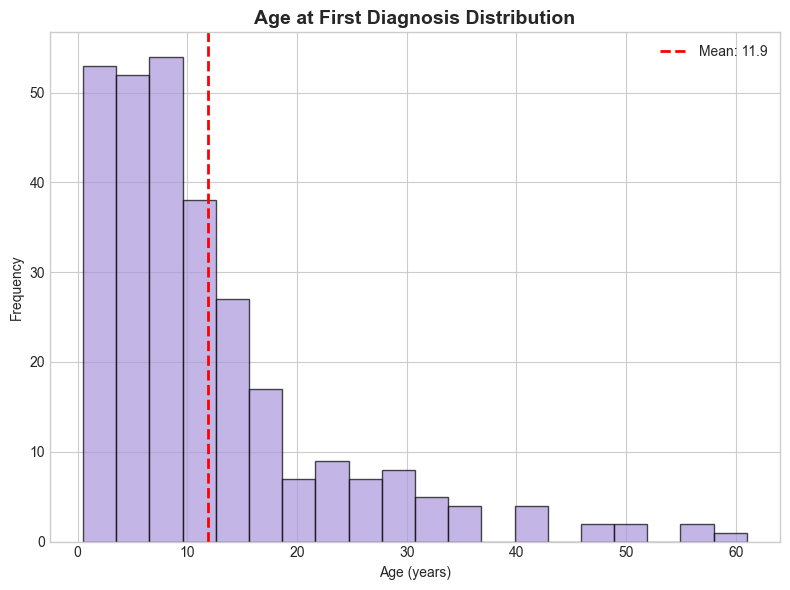

In [22]:
# Age at First Diagnosis distribution
plt.figure(figsize=(8, 6))
mean_age = df['Age at First Diagnosis'].mean()

df['Age at First Diagnosis'].hist(bins=20, color='#AA96DA', edgecolor='black', alpha=0.7)

plt.title('Age at First Diagnosis Distribution', fontweight='bold', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

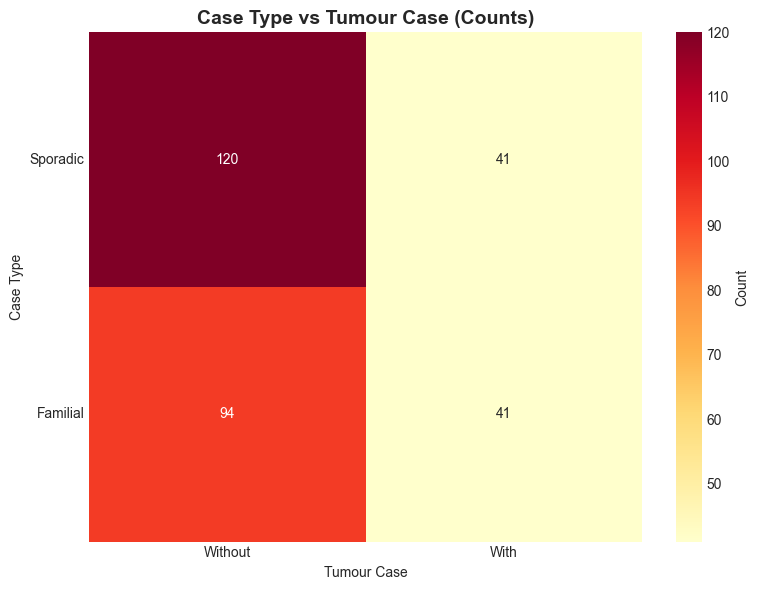

In [25]:
# Cross-tabulation heatmap
plt.figure(figsize=(8, 6))
# Creating the actual count crosstab for the heatmap
crosstab = pd.crosstab(df['Case Type'], df['Tumour Case'])

sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})

plt.title('Case Type vs Tumour Case (Counts)', fontweight='bold', fontsize=14)
plt.xlabel('Tumour Case')
plt.ylabel('Case Type')
plt.xticks([0.5, 1.5], ['Without', 'With'])
plt.yticks([0.5, 1.5], ['Sporadic', 'Familial'], rotation=0)

plt.tight_layout()
plt.show()

## Age Analysis

<Figure size 800x600 with 0 Axes>

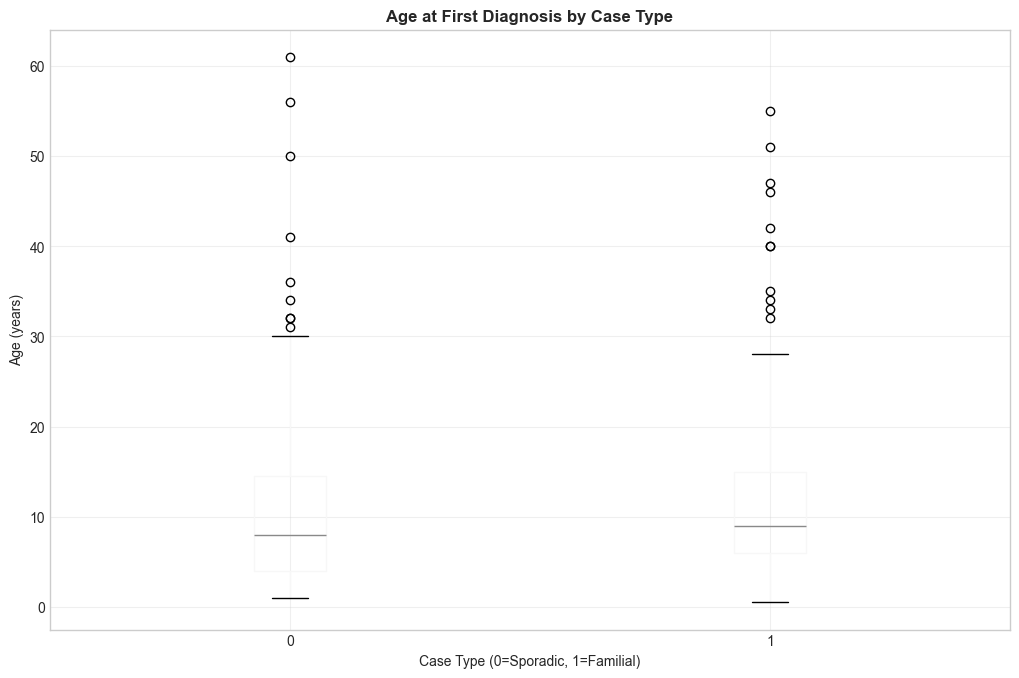

In [26]:
# Boxplot: Age vs Case Type
plt.figure(figsize=(8, 6))
df.boxplot(column='Age at First Diagnosis', by='Case Type')

plt.title('Age at First Diagnosis by Case Type', fontweight='bold')
plt.suptitle('') # Removes the automatic pandas subtitle
plt.xlabel('Case Type (0=Sporadic, 1=Familial)')
plt.ylabel('Age (years)')
plt.grid(True, alpha=0.3)

plt.show()

<Figure size 800x600 with 0 Axes>

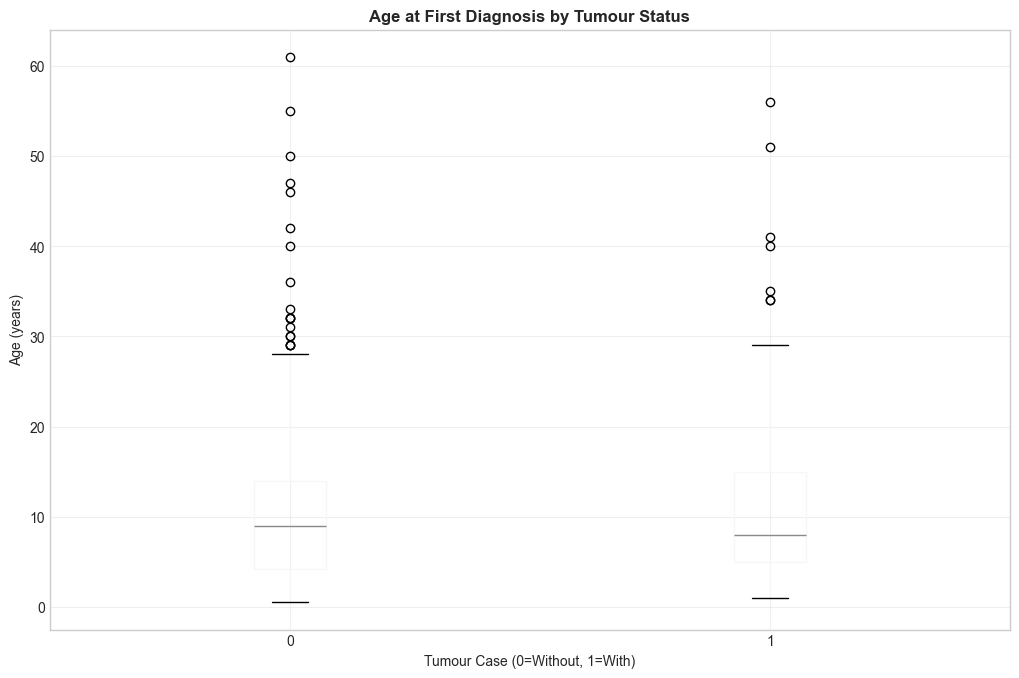

In [27]:
# Boxplot: Age vs Tumour Status
plt.figure(figsize=(8, 6))
df.boxplot(column='Age at First Diagnosis', by='Tumour Case')

plt.title('Age at First Diagnosis by Tumour Status', fontweight='bold')
plt.suptitle('') # Removes the automatic pandas subtitle
plt.xlabel('Tumour Case (0=Without, 1=With)')
plt.ylabel('Age (years)')
plt.grid(True, alpha=0.3)

plt.show()

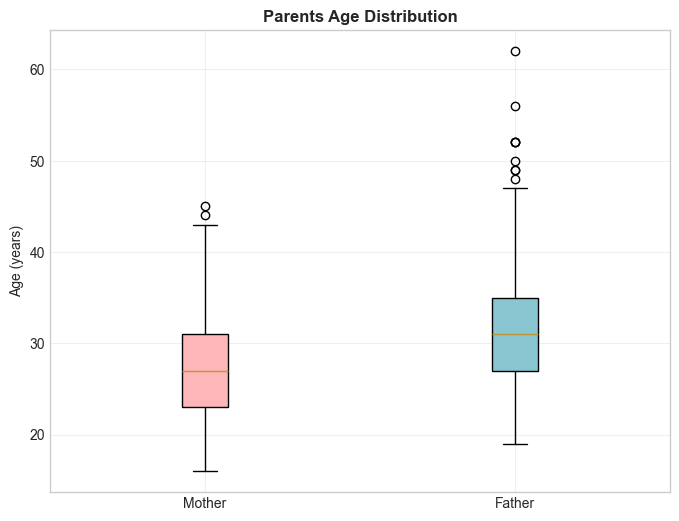

In [28]:
# Comparison of Mother vs Father age distributions
plt.figure(figsize=(8, 6))

# Prepare data and drop NaNs for plotting
age_data = [df['Age of Mother'].dropna(), df['Age of Father'].dropna()]

bp = plt.boxplot(age_data, labels=['Mother', 'Father'], patch_artist=True)

# Custom colors
colors = ['#FFB6B9', '#8AC6D1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Parents Age Distribution', fontweight='bold')
plt.ylabel('Age (years)')
plt.grid(True, alpha=0.3)

plt.show()

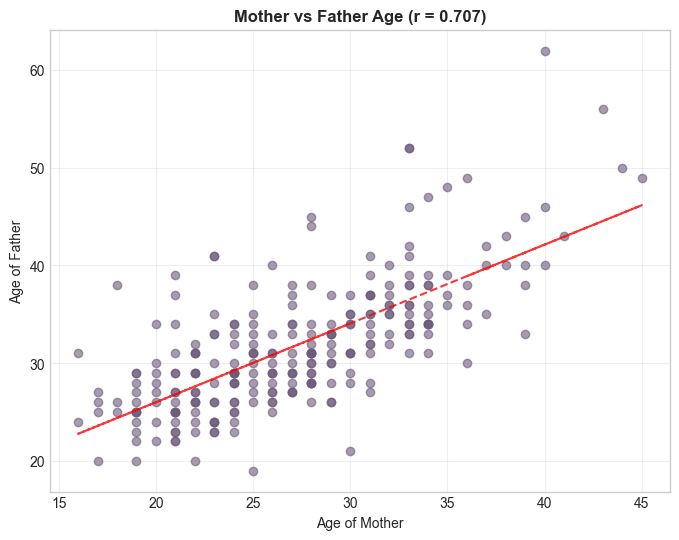

In [29]:
plt.figure(figsize=(8, 6))

# Clean data for correlation
valid_ages = df[['Age of Mother', 'Age of Father']].dropna()

# Scatter plot
plt.scatter(valid_ages['Age of Mother'], valid_ages['Age of Father'], 
            alpha=0.6, color='#6C5B7B')

# Calculate correlation and trend line
corr = valid_ages.corr().iloc[0,1]
z = np.polyfit(valid_ages['Age of Mother'], valid_ages['Age of Father'], 1)
p = np.poly1d(z)

# Plot trend line
plt.plot(valid_ages['Age of Mother'], p(valid_ages['Age of Mother']), "r--", alpha=0.8)

plt.title(f'Mother vs Father Age (r = {corr:.3f})', fontweight='bold')
plt.xlabel('Age of Mother')
plt.ylabel('Age of Father')
plt.grid(True, alpha=0.3)

plt.show()

In [30]:
from scipy import stats

print("\n" + "=" * 70)
print("STATISTICAL TESTS - AGE DIFFERENCES")
print("=" * 70)

# 1. T-test for Case Type
sporadic_age = df[df['Case Type'] == 0]['Age at First Diagnosis'].dropna()
familial_age = df[df['Case Type'] == 1]['Age at First Diagnosis'].dropna()
t_stat, p_val = stats.ttest_ind(sporadic_age, familial_age)

print(f"\n[Age at First Diagnosis by Case Type]")
print(f"Sporadic: Mean={sporadic_age.mean():.2f}, SD={sporadic_age.std():.2f}")
print(f"Familial: Mean={familial_age.mean():.2f}, SD={familial_age.std():.2f}")
print(f"T-test: t={t_stat:.3f}, p={p_val:.4f}")

# 2. T-test for Tumour Status
no_tumour_age = df[df['Tumour Case'] == 0]['Age at First Diagnosis'].dropna()
tumour_age = df[df['Tumour Case'] == 1]['Age at First Diagnosis'].dropna()
t_stat2, p_val2 = stats.ttest_ind(no_tumour_age, tumour_age)

print(f"\n[Age at First Diagnosis by Tumour Status]")
print(f"Without Tumours: Mean={no_tumour_age.mean():.2f}, SD={no_tumour_age.std():.2f}")
print(f"With Tumours: Mean={tumour_age.mean():.2f}, SD={tumour_age.std():.2f}")
print(f"T-test: t={t_stat2:.3f}, p={p_val2:.4f}")


STATISTICAL TESTS - AGE DIFFERENCES

[Age at First Diagnosis by Case Type]
Sporadic: Mean=11.50, SD=10.65
Familial: Mean=12.33, SD=10.85
T-test: t=-0.664, p=0.5074

[Age at First Diagnosis by Tumour Status]
Without Tumours: Mean=11.73, SD=10.45
With Tumours: Mean=12.27, SD=11.47
T-test: t=-0.387, p=0.6988


## Clinical Features Analysis

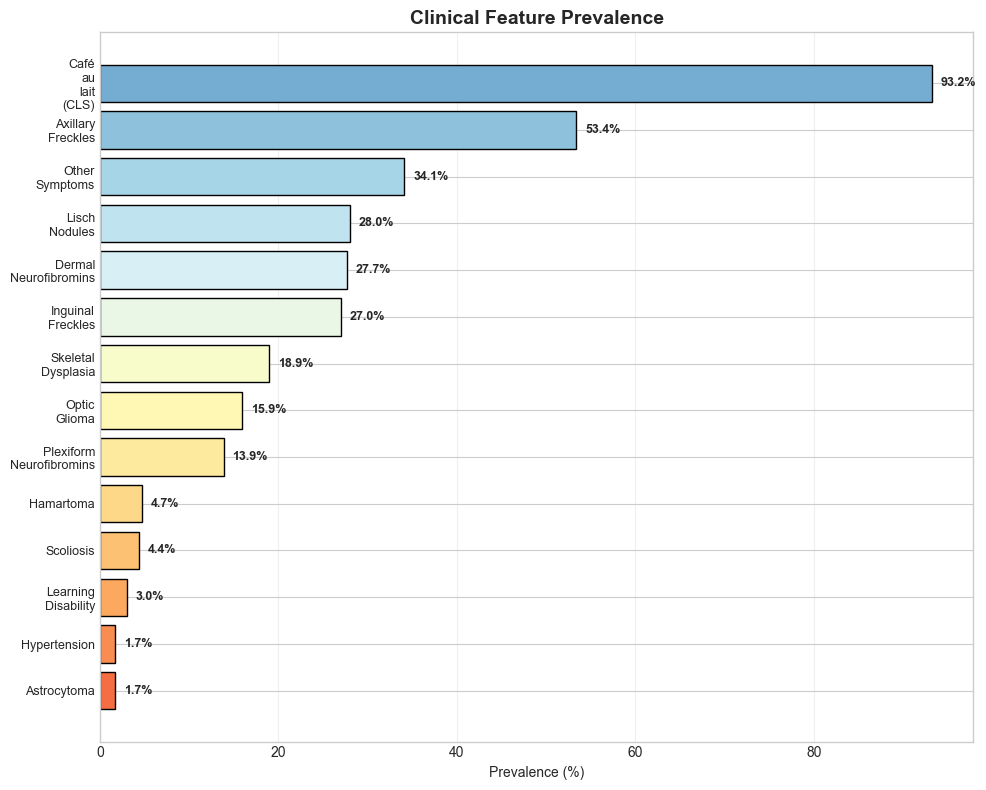

In [31]:
# Setup features list
clinical_features = ['Café au lait (CLS)', 'Axillary Freckles', 'Inguinal Freckles', 
                     'Lisch Nodules', 'Dermal Neurofibromins', 'Plexiform Neurofibromins',
                     'Optic Glioma', 'Skeletal Dysplasia', 'Learning Disability', 
                     'Hypertension', 'Astrocytoma', 'Hamartoma', 'Scoliosis', 'Other Symptoms']

# Calculate prevalence
prevalence = df[clinical_features].mean() * 100
prevalence_sorted = prevalence.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(prevalence_sorted)))
bars = plt.barh(range(len(prevalence_sorted)), prevalence_sorted.values, 
                color=colors, edgecolor='black')

plt.yticks(range(len(prevalence_sorted)), [f.replace(' ', '\n') for f in prevalence_sorted.index], fontsize=9)
plt.xlabel('Prevalence (%)')
plt.title('Clinical Feature Prevalence', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Add percentage labels to the end of bars
for bar, val in zip(bars, prevalence_sorted.values):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

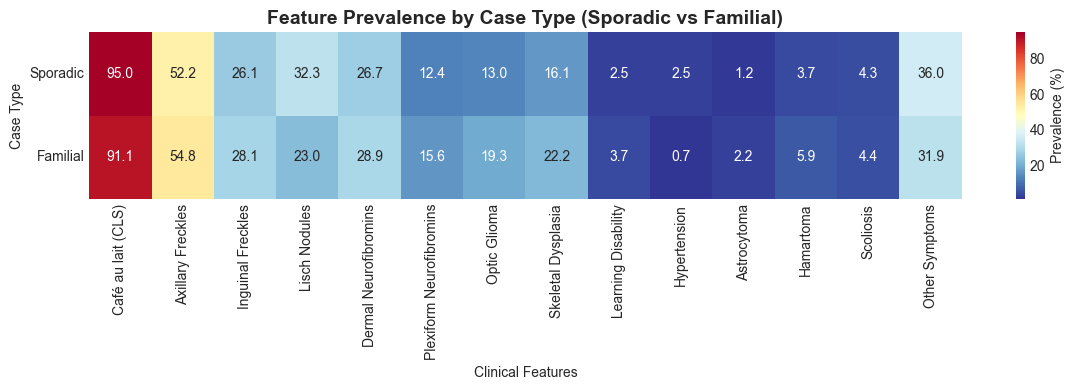

In [33]:
# Feature Prevalence by Case Type (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
feature_by_case = df.groupby('Case Type')[clinical_features].mean() * 100

sns.heatmap(feature_by_case, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            cbar_kws={'label': 'Prevalence (%)'})

plt.title('Feature Prevalence by Case Type (Sporadic vs Familial)', fontweight='bold', fontsize=14)

# FIX: Use plt.yticks instead of plt.yticklabels
plt.yticks([0.5, 1.5], ['Sporadic', 'Familial'], rotation=0)

plt.xlabel('Clinical Features')
plt.tight_layout()
plt.show()

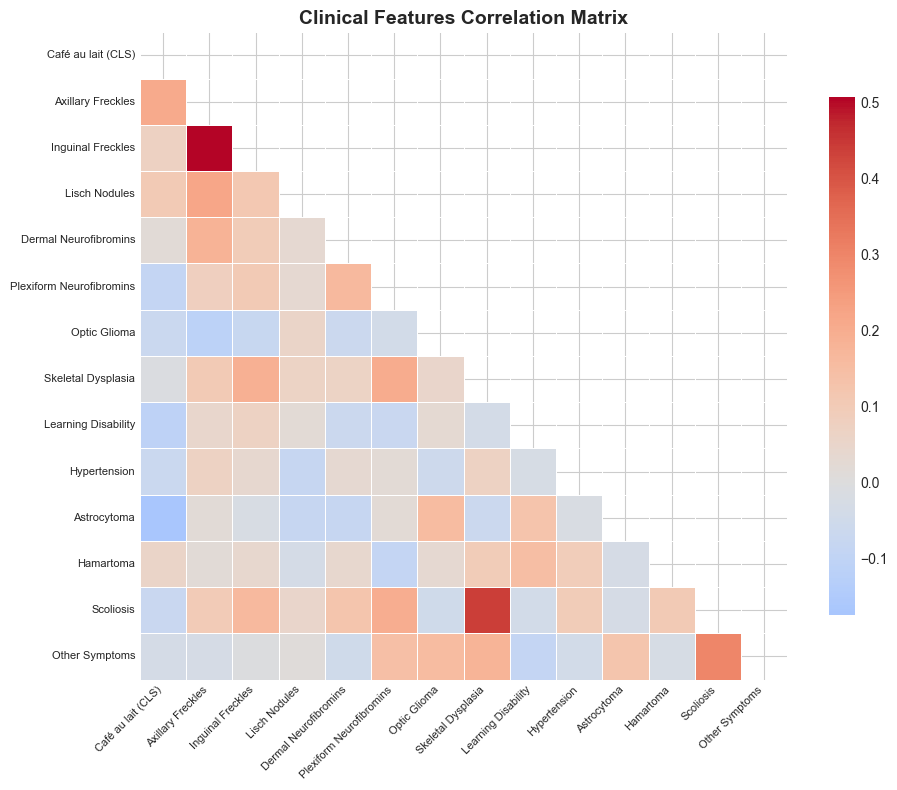

In [34]:
# Clinical Features Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df[clinical_features].corr()

# Create a mask for the upper triangle to make it easier to read
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Clinical Features Correlation Matrix', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

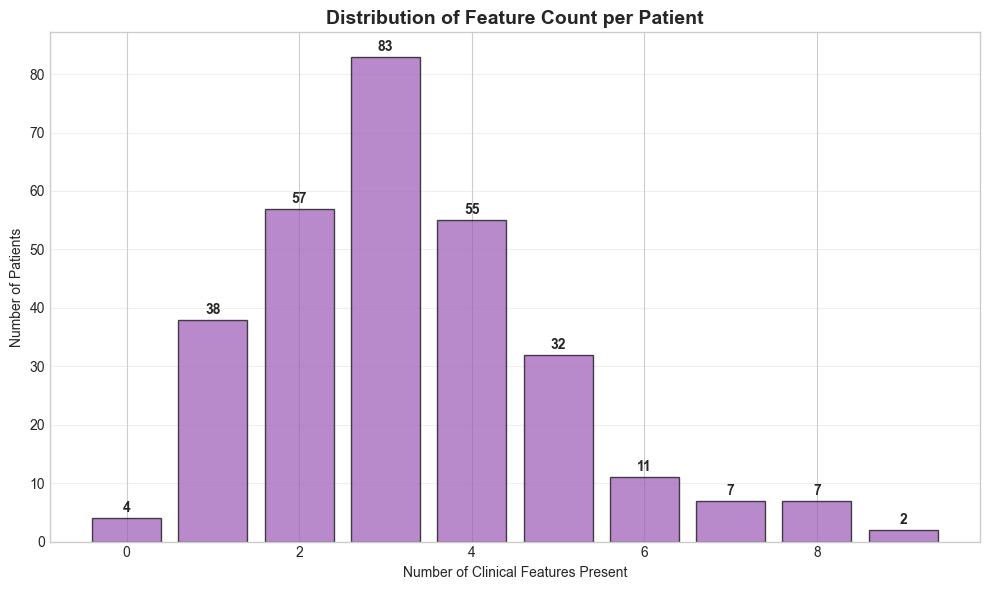


Clinical Features Prevalence (Top 10):
  Café au lait (CLS): 93.2%
  Axillary Freckles: 53.4%
  Other Symptoms: 34.1%
  Lisch Nodules: 28.0%
  Dermal Neurofibromins: 27.7%
  Inguinal Freckles: 27.0%
  Skeletal Dysplasia: 18.9%
  Optic Glioma: 15.9%
  Plexiform Neurofibromins: 13.9%
  Hamartoma: 4.7%


In [35]:
# Distribution of Feature Count per Patient
# Create the feature count variable first
df['Feature_Count'] = df[clinical_features].sum(axis=1)

plt.figure(figsize=(10, 6))
feature_count_dist = df['Feature_Count'].value_counts().sort_index()

plt.bar(feature_count_dist.index, feature_count_dist.values, color='#9B59B6', 
        edgecolor='black', alpha=0.7)

plt.xlabel('Number of Clinical Features Present')
plt.ylabel('Number of Patients')
plt.title('Distribution of Feature Count per Patient', fontweight='bold', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add count labels on top of bars
for i, v in enumerate(feature_count_dist.values):
    plt.text(feature_count_dist.index[i], v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print the text summary
print("\nClinical Features Prevalence (Top 10):")
for feature, prev in prevalence.sort_values(ascending=False).head(10).items():
    print(f"  {feature}: {prev:.1f}%")

## Association Analysis

In [36]:
results = []
for feature in clinical_features:
    # Association with Case Type
    ct_table = pd.crosstab(df[feature], df['Case Type'])
    chi2_case, p_case, _, _ = chi2_contingency(ct_table)
    
    # Association with Tumour Case
    ct_table2 = pd.crosstab(df[feature], df['Tumour Case'])
    chi2_tumour, p_tumour, _, _ = chi2_contingency(ct_table2)
    
    results.append({
        'Feature': feature,
        'Chi2_CaseType': chi2_case,
        'P_CaseType': p_case,
        'Chi2_Tumour': chi2_tumour,
        'P_Tumour': p_tumour
    })

results_df = pd.DataFrame(results)
print("\nSignificant Associations with Tumour Case (p < 0.05):")
sig_tumour = results_df[results_df['P_Tumour'] < 0.05].sort_values('P_Tumour')
for _, row in sig_tumour.iterrows():
    print(f"  {row['Feature']}: p = {row['P_Tumour']:.2e}")


Significant Associations with Tumour Case (p < 0.05):
  Optic Glioma: p = 2.44e-27
  Other Symptoms: p = 5.18e-19
  Astrocytoma: p = 1.69e-03
  Café au lait (CLS): p = 4.05e-02


## Tumour Risk Analysis

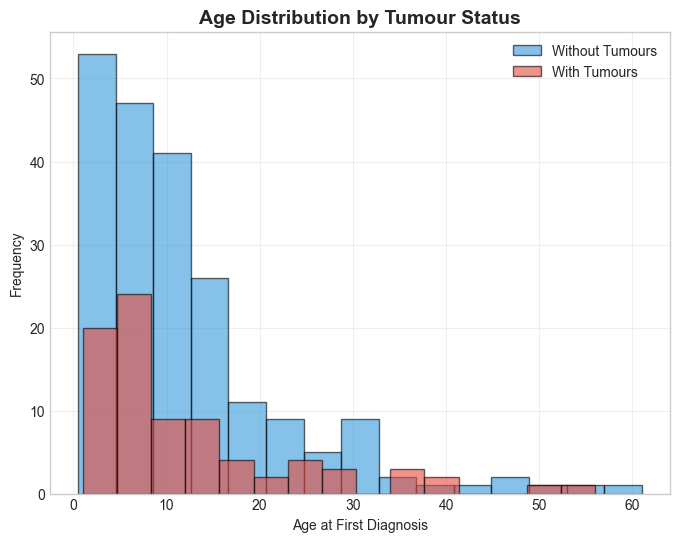

In [37]:

# Separate data by tumour status
no_tumour = df[df['Tumour Case'] == 0]['Age at First Diagnosis'].dropna()
with_tumour = df[df['Tumour Case'] == 1]['Age at First Diagnosis'].dropna()

plt.figure(figsize=(8, 6))
plt.hist(no_tumour, bins=15, alpha=0.6, label='Without Tumours', 
         color='#3498DB', edgecolor='black')
plt.hist(with_tumour, bins=15, alpha=0.6, label='With Tumours', 
         color='#E74C3C', edgecolor='black')

plt.xlabel('Age at First Diagnosis')
plt.ylabel('Frequency')
plt.title('Age Distribution by Tumour Status', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

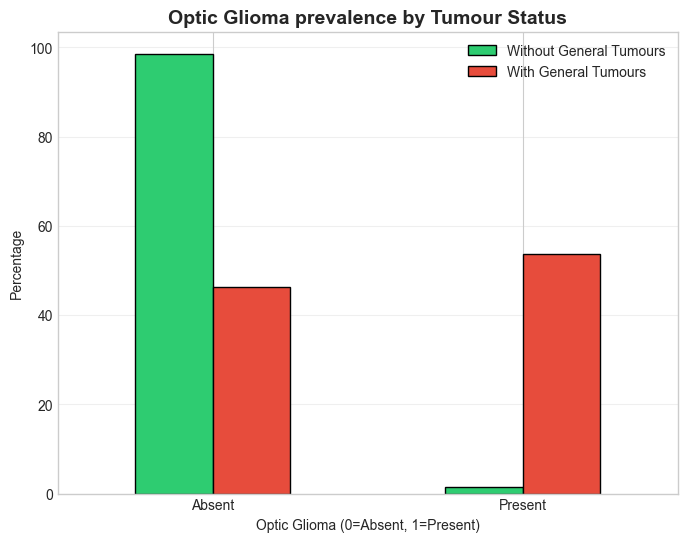

In [38]:
# Normalize data to show percentages rather than raw counts
optic_crosstab = pd.crosstab(df['Optic Glioma'], df['Tumour Case'], normalize='columns') * 100

# Use the plot method from pandas but manage the layout with plt
optic_crosstab.plot(kind='bar', figsize=(8, 6), color=['#2ECC71', '#E74C3C'], edgecolor='black')

plt.title('Optic Glioma prevalence by Tumour Status', fontweight='bold', fontsize=14)
plt.xlabel('Optic Glioma (0=Absent, 1=Present)')
plt.ylabel('Percentage')
plt.legend(['Without General Tumours', 'With General Tumours'])
plt.xticks([0, 1], ['Absent', 'Present'], rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

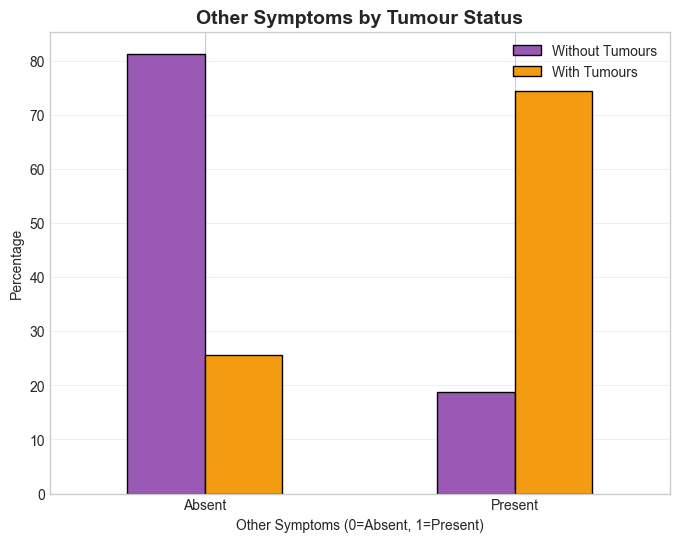

In [39]:
# Normalize data to columns to compare the likelihood within each group
other_crosstab = pd.crosstab(df['Other Symptoms'], df['Tumour Case'], normalize='columns') * 100

other_crosstab.plot(kind='bar', figsize=(8, 6), color=['#9B59B6', '#F39C12'], edgecolor='black')

plt.title('Other Symptoms by Tumour Status', fontweight='bold', fontsize=14)
plt.xlabel('Other Symptoms (0=Absent, 1=Present)')
plt.ylabel('Percentage')
plt.legend(['Without Tumours', 'With Tumours'])
plt.xticks([0, 1], ['Absent', 'Present'], rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

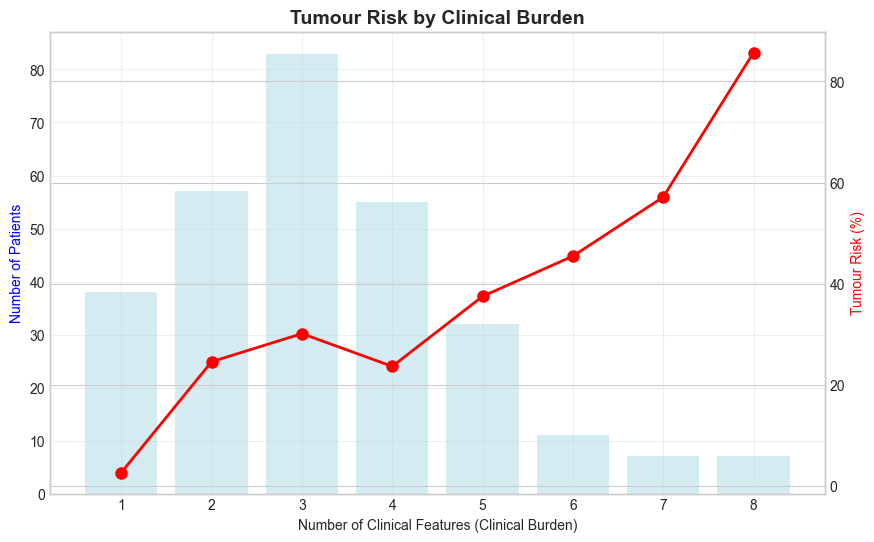

In [40]:
# Calculate risk: the mean of 'Tumour Case' (0 or 1) is effectively the probability
feature_risk = df.groupby('Feature_Count')['Tumour Case'].agg(['count', 'mean']).reset_index()

# Filter for statistical relevance (only counts with 5+ patients)
feature_risk = feature_risk[feature_risk['count'] >= 5]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Bar chart for Patient Count
ax1.bar(feature_risk['Feature_Count'], feature_risk['count'], 
        alpha=0.5, color='lightblue', label='Patient Count')
ax1.set_xlabel('Number of Clinical Features (Clinical Burden)')
ax1.set_ylabel('Number of Patients', color='blue')
ax1.grid(True, alpha=0.3)

# Secondary Axis: Line plot for Risk Percentage
ax2 = ax1.twinx()
ax2.plot(feature_risk['Feature_Count'], feature_risk['mean'] * 100, 
         'ro-', linewidth=2, markersize=8, label='Tumour Risk %')
ax2.set_ylabel('Tumour Risk (%)', color='red')

plt.title('Tumour Risk by Clinical Burden', fontweight='bold', fontsize=14)
plt.show()

In [41]:
print("\n" + "=" * 70)
print("TUMOUR CASE ANALYSIS - DETAILED BREAKDOWN")
print("=" * 70)

# 1. Optic Glioma Breakdown
print("\n1. OPTIC GLIOMA Association:")
optic_tumour = pd.crosstab(df['Optic Glioma'], df['Tumour Case'], margins=True)
print(optic_tumour)
print(f"\nOf patients WITH tumours: {(optic_tumour.loc[1, 1] / optic_tumour.loc['All', 1] * 100):.1f}% have Optic Glioma")
print(f"Of patients WITHOUT tumours: {(optic_tumour.loc[1, 0] / optic_tumour.loc['All', 0] * 100):.1f}% have Optic Glioma")

# 2. Other Symptoms Breakdown
print("\n2. OTHER SYMPTOMS Association:")
other_tumour = pd.crosstab(df['Other Symptoms'], df['Tumour Case'], margins=True)
print(other_tumour)
print(f"\nOf patients WITH tumours: {(other_tumour.loc[1, 1] / other_tumour.loc['All', 1] * 100):.1f}% have Other Symptoms")
print(f"Of patients WITHOUT tumours: {(other_tumour.loc[1, 0] / other_tumour.loc['All', 0] * 100):.1f}% have Other Symptoms")


TUMOUR CASE ANALYSIS - DETAILED BREAKDOWN

1. OPTIC GLIOMA Association:
Tumour Case     0   1  All
Optic Glioma              
0             211  38  249
1               3  44   47
All           214  82  296

Of patients WITH tumours: 53.7% have Optic Glioma
Of patients WITHOUT tumours: 1.4% have Optic Glioma

2. OTHER SYMPTOMS Association:
Tumour Case       0   1  All
Other Symptoms              
0               174  21  195
1                40  61  101
All             214  82  296

Of patients WITH tumours: 74.4% have Other Symptoms
Of patients WITHOUT tumours: 18.7% have Other Symptoms


## Summary Dashboard

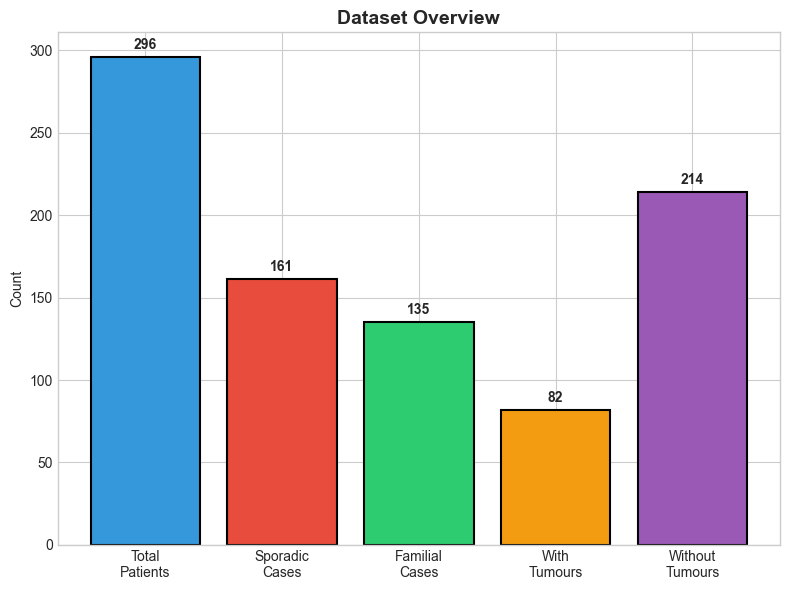

In [42]:
plt.figure(figsize=(8, 6))

metrics = ['Total\nPatients', 'Sporadic\nCases', 'Familial\nCases', 'With\nTumours', 'Without\nTumours']
values = [296, 161, 135, 82, 214]
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']

bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5)

plt.title('Dataset Overview', fontweight='bold', fontsize=14)
plt.ylabel('Count')

# Add value labels on top of bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3, str(val), 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

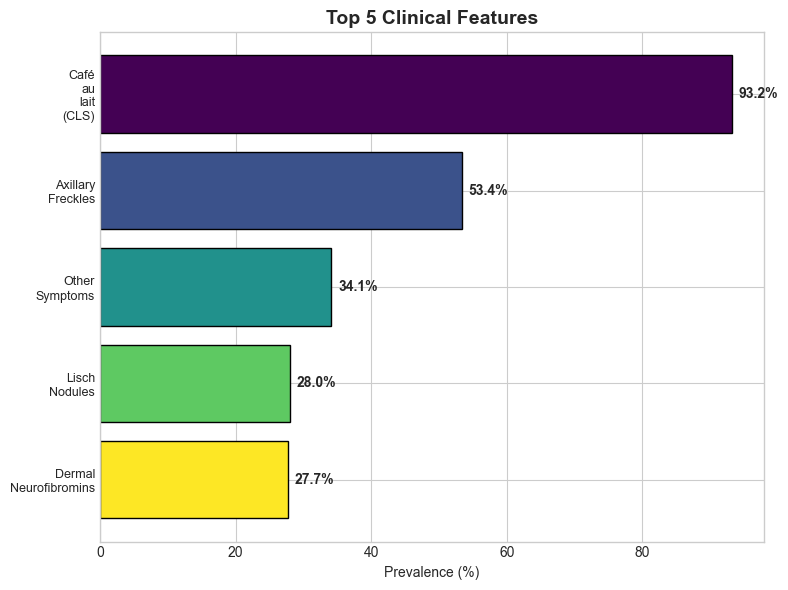

In [43]:
# Clinical Features
plt.figure(figsize=(8, 6))

# Assuming 'prevalence' was calculated in previous cells
top5_features = prevalence.sort_values(ascending=False).head(5)

plt.barh(range(len(top5_features)), top5_features.values, 
         color=plt.cm.viridis(np.linspace(0, 1, 5)), edgecolor='black')

plt.yticks(range(len(top5_features)), [f.replace(' ', '\n') for f in top5_features.index], fontsize=9)
plt.xlabel('Prevalence (%)')
plt.title('Top 5 Clinical Features', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()

for i, v in enumerate(top5_features.values):
    plt.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

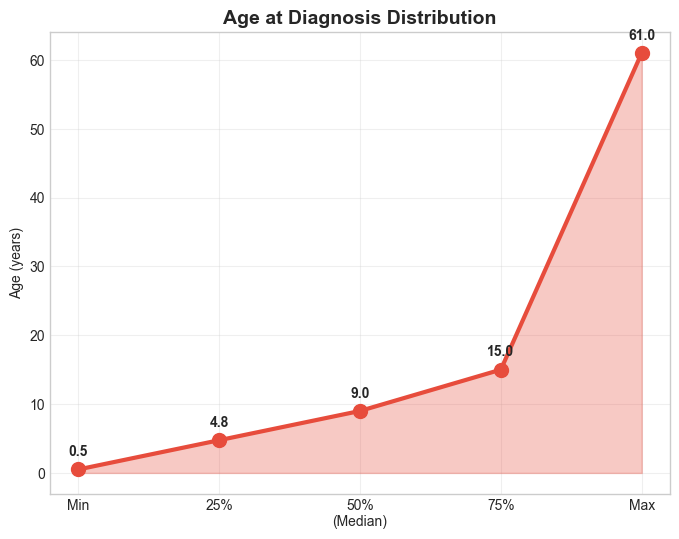

In [44]:
# Age and diagonosis distribution 
plt.figure(figsize=(8, 6))

age_stats = df['Age at First Diagnosis'].describe()
stats_labels = ['Min', '25%', '50%\n(Median)', '75%', 'Max']
stats_values = [age_stats['min'], age_stats['25%'], age_stats['50%'], age_stats['75%'], age_stats['max']]

plt.plot(stats_labels, stats_values, marker='o', linewidth=3, markersize=10, color='#E74C3C')
plt.fill_between(stats_labels, stats_values, alpha=0.3, color='#E74C3C')

plt.title('Age at Diagnosis Distribution', fontweight='bold', fontsize=14)
plt.ylabel('Age (years)')
plt.grid(True, alpha=0.3)

for i, v in enumerate(stats_values):
    plt.text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

plt.show()

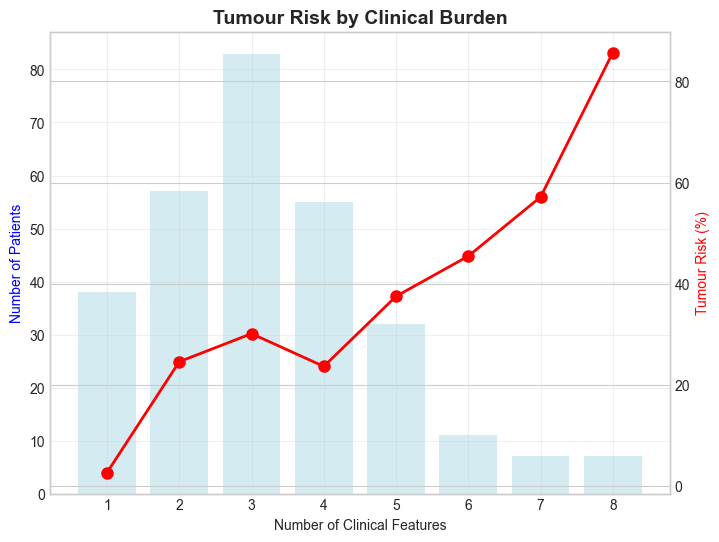

In [45]:
# Tumor Risk 
# Assuming 'feature_risk' was calculated in previous cells
fig, ax1 = plt.subplots(figsize=(8, 6))
ax2 = ax1.twinx()

ax1.bar(feature_risk['Feature_Count'], feature_risk['count'], 
        alpha=0.5, color='lightblue', label='Patient Count')
ax2.plot(feature_risk['Feature_Count'], feature_risk['mean'] * 100, 
         'ro-', linewidth=2, markersize=8, label='Tumour Risk %')

ax1.set_xlabel('Number of Clinical Features')
ax1.set_ylabel('Number of Patients', color='blue')
ax2.set_ylabel('Tumour Risk (%)', color='red')
plt.title('Tumour Risk by Clinical Burden', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)

plt.show()

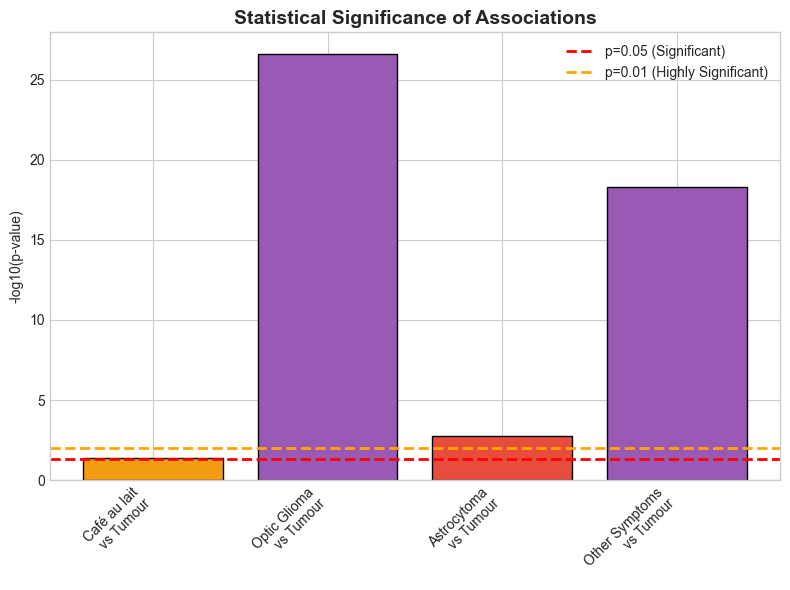

In [46]:
# statistical significance 
plt.figure(figsize=(8, 6))

associations = ['Café au lait\nvs Tumour', 'Optic Glioma\nvs Tumour', 
                'Astrocytoma\nvs Tumour', 'Other Symptoms\nvs Tumour']
p_values = [0.040, 2.44e-27, 0.0017, 5.18e-19]

# Colors based on significance level
colors_assoc = ['#F39C12' if p > 0.01 else '#E74C3C' if p > 1e-10 else '#9B59B6' for p in p_values]

plt.bar(associations, [-np.log10(p) for p in p_values], color=colors_assoc, edgecolor='black')
plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05 (Significant)')
plt.axhline(y=-np.log10(0.01), color='orange', linestyle='--', linewidth=2, label='p=0.01 (Highly Significant)')

plt.ylabel('-log10(p-value)')
plt.title('Statistical Significance of Associations', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend()

plt.tight_layout()
plt.show()

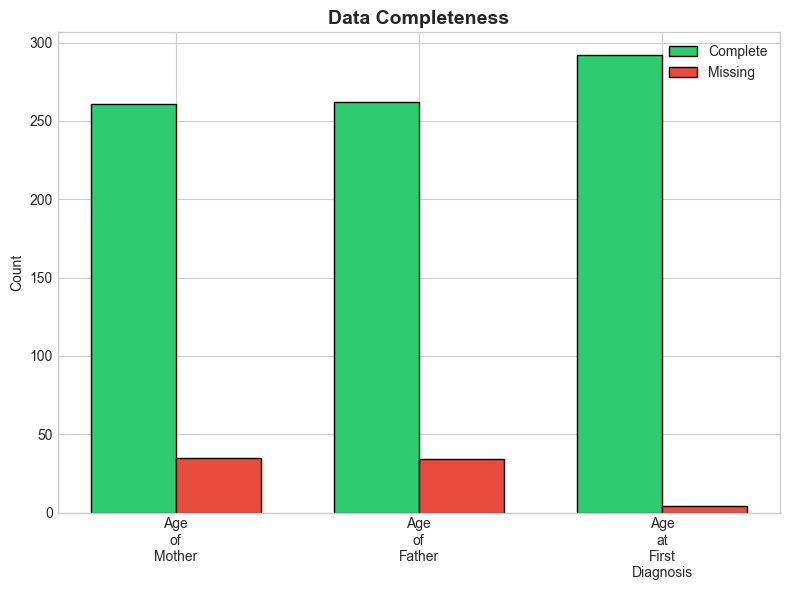

In [ ]:
# data completeness
plt.figure(figsize=(8, 6))

missing_cols = ['Age of Mother', 'Age of Father', 'Age at First Diagnosis']
missing_counts = [df[col].isnull().sum() for col in missing_cols]
complete_counts = [len(df) - m for m in missing_counts]

x = np.arange(len(missing_cols))
width = 0.35

plt.bar(x - width/2, complete_counts, width, label='Complete', color='#2ECC71', edgecolor='black')
plt.bar(x + width/2, missing_counts, width, label='Missing', color='#E74C3C', edgecolor='black')

plt.ylabel('Count')
plt.title('Data Completeness', fontweight='bold', fontsize=14)
plt.xticks(x, [c.replace(' ', '\n') for c in missing_cols])
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
# Cell 11: Final Summary
print("\n" + "=" * 70)
print("EXECUTIVE SUMMARY - KEY FINDINGS")
print("=" * 70)
print(f"""
DATASET OVERVIEW:
• Total Patients: {len(df)}
• Sporadic Cases: {(df['Case Type']==0).sum()} ({(df['Case Type']==0).mean()*100:.1f}%)
• Familial Cases: {(df['Case Type']==1).sum()} ({(df['Case Type']==1).mean()*100:.1f}%)
• Patients with Tumours: {(df['Tumour Case']==1).sum()} ({(df['Tumour Case']==1).mean()*100:.1f}%)

CLINICAL PROFILE:
• Most Common Feature: Café au lait spots ({prevalence['Café au lait (CLS)']:.1f}%)
• Average Age at Diagnosis: {df['Age at First Diagnosis'].mean():.1f} years
• Average Features per Patient: {df['Feature_Count'].mean():.1f}

KEY ASSOCIATIONS WITH TUMOUR DEVELOPMENT:
• Optic Glioma: Strongest predictor (p < 0.001)
  - 53.7% of tumour patients have Optic Glioma vs 1.4% without tumours
• Other Symptoms: Very strong association (p < 0.001)
  - 74.4% of tumour patients have other symptoms vs 18.7% without
• Astrocytoma: Significant association (p < 0.01)
• Café au lait spots: Moderate association (p < 0.05)

NO SIGNIFICANT DIFFERENCES:
• Age at diagnosis between sporadic and familial cases (p=0.51)
• Age at diagnosis between tumour and non-tumour patients (p=0.70)
• Most clinical features show no association with case type (sporadic vs familial)

CLINICAL IMPLICATIONS:
1. Optic Glioma is the strongest single predictor of tumour development
2. Patients with multiple clinical features have higher tumour risk
3. Familial and sporadic cases show similar clinical presentation
4. Early diagnosis (median age 9 years) is common in this cohort
""")


EXECUTIVE SUMMARY - KEY FINDINGS

DATASET OVERVIEW:
• Total Patients: 296
• Sporadic Cases: 161 (54.4%)
• Familial Cases: 135 (45.6%)
• Patients with Tumours: 82 (27.7%)

CLINICAL PROFILE:
• Most Common Feature: Café au lait spots (93.2%)
• Average Age at Diagnosis: 11.9 years
• Average Features per Patient: 3.3

KEY ASSOCIATIONS WITH TUMOUR DEVELOPMENT:
• Optic Glioma: Strongest predictor (p < 0.001)
  - 53.7% of tumour patients have Optic Glioma vs 1.4% without tumours
• Other Symptoms: Very strong association (p < 0.001)
  - 74.4% of tumour patients have other symptoms vs 18.7% without
• Astrocytoma: Significant association (p < 0.01)
• Café au lait spots: Moderate association (p < 0.05)

NO SIGNIFICANT DIFFERENCES:
• Age at diagnosis between sporadic and familial cases (p=0.51)
• Age at diagnosis between tumour and non-tumour patients (p=0.70)
• Most clinical features show no association with case type (sporadic vs familial)

CLINICAL IMPLICATIONS:
1. Optic Glioma is the strongest

# 🏁 Clinical Implications & Conclusions

Based on the statistical outputs and visualized distributions, the following conclusions are drawn:

1. **Surveillance Priority:** Patients presenting with **Optic Glioma** or a high **Feature Count** (average $> 3.3$) should be monitored more aggressively for broader tumour developments.
2. **Clinical Consistency:** There is a remarkable similarity in clinical manifestations between sporadic and familial Neurofibromatosis, suggesting that the genetic mechanism expresses similarly regardless of heritage.
3. **Age Thresholds:** The concentration of diagnoses around age 9-12 highlights a critical window for pediatric clinical intervention.

---